####Imports & Installations

In [23]:
import pandas as pd
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [24]:
main_directory = '/content/drive/My Drive/Barnabus Project/'
insights_df = pd.read_csv(f'{main_directory}outputs/complete_cluster_insights.csv')

df = pd.read_csv(f'{main_directory}data/processed/analyzed_data.csv')

top_10 = pd.read_csv(f'{main_directory}outputs/top_10_recurring_issues.csv')

print(f"Data summary:")
print(f"   Total clusters: {len(insights_df)}")
print(f"   Total patients: {len(df)}")

Data summary:
   Total clusters: 20
   Total patients: 6000


####Recommendation Rules

In [25]:
RECOMMENDATION_TEMPLATES = {
    # Waiting time related
    'waiting': {
        'keywords': ['wart', 'wait', 'long', 'delay', 'spät', 'attente', 'انتظار'],
        'actions': [
            'Implement appointment reminder system to reduce no-shows',
            'Optimize scheduling algorithm to reduce wait times',
            'Add real-time wait time notifications',
            'Increase staff during peak hours',
            'Introduce queue management system'
        ],
        'category': 'Operational Efficiency'
    },

    # Staff/service quality
    'staff': {
        'keywords': ['freundlich', 'friendly', 'staff', 'personal', 'service', 'personnel', 'موظف'],
        'actions': [
            'Implement staff recognition program',
            'Provide customer service training',
            'Establish patient feedback loop to staff',
            'Create staff satisfaction initiatives',
            'Document and share best practices'
        ],
        'category': 'Staff Development'
    },

    # Communication issues
    'communication': {
        'keywords': ['erkl', 'explain', 'inform', 'communication', 'verständ', 'expli', 'تواصل'],
        'actions': [
            'Develop standardized patient communication protocols',
            'Provide communication skills training',
            'Create multilingual information materials',
            'Implement post-visit summary emails',
            'Establish clear escalation procedures'
        ],
        'category': 'Communication'
    },

    # Billing/administrative
    'billing': {
        'keywords': ['rechnun', 'billing', 'payment', 'insurance', 'kosten', 'facturation', 'فاتورة'],
        'actions': [
            'Automate invoice generation and follow-up',
            'Provide clear cost estimates upfront',
            'Simplify insurance claim process',
            'Offer transparent pricing information',
            'Create billing FAQ resources'
        ],
        'category': 'Administrative'
    },

    # Appointment/access
    'appointment': {
        'keywords': ['termin', 'appointment', 'access', 'verfügbar', 'rendez-vous', 'موعد'],
        'actions': [
            'Expand online booking capabilities',
            'Increase appointment availability',
            'Implement flexible scheduling options',
            'Add emergency appointment slots',
            'Send appointment confirmations and reminders'
        ],
        'category': 'Access & Availability'
    },

    # Facility/environment
    'facility': {
        'keywords': ['clean', 'sauber', 'facility', 'room', 'raum', 'propre', 'نظيف'],
        'actions': [
            'Enhance cleaning protocols and frequency',
            'Upgrade facility equipment and furnishings',
            'Improve waiting area comfort',
            'Ensure proper maintenance schedule',
            'Conduct regular facility inspections'
        ],
        'category': 'Facility Management'
    },

    # Treatment/medical care
    'treatment': {
        'keywords': ['behandl', 'treatment', 'care', 'medical', 'diagnos', 'traitement', 'علاج'],
        'actions': [
            'Implement clinical quality improvement program',
            'Provide continuing medical education',
            'Establish treatment protocol reviews',
            'Create patient care pathways',
            'Enhance post-treatment follow-up'
        ],
        'category': 'Clinical Quality'
    }
}

print(f"Loaded {len(RECOMMENDATION_TEMPLATES)} recommendation categories:")
for key, template in RECOMMENDATION_TEMPLATES.items():
    print(f"   • {template['category']}")

Loaded 7 recommendation categories:
   • Operational Efficiency
   • Staff Development
   • Communication
   • Administrative
   • Access & Availability
   • Facility Management
   • Clinical Quality


####Classify

In [26]:
def classify_cluster_category(keywords_str, summary):
    """
    Classify cluster into recommendation category based on keywords and summary

    Returns: category_name, matched_template, confidence_score
    """
    keywords_lower = keywords_str.lower() if isinstance(keywords_str, str) else ""
    summary_lower = summary.lower() if isinstance(summary, str) else ""

    combined_text = keywords_lower + " " + summary_lower

    template_scores = {}
    for template_name, template in RECOMMENDATION_TEMPLATES.items():
        score = 0
        for keyword in template['keywords']:
            if keyword in combined_text:
                score += 1
        template_scores[template_name] = score

    if max(template_scores.values()) > 0:
        best_template = max(template_scores, key=template_scores.get)
        confidence = template_scores[best_template] / len(RECOMMENDATION_TEMPLATES[best_template]['keywords'])
        return RECOMMENDATION_TEMPLATES[best_template]['category'], best_template, confidence
    else:
        return 'General Improvement', 'general', 0.0


def calculate_severity(row):
    """
    Calculate severity score based on:
    - Negative sentiment percentage
    - Cluster size (volume)
    - Rating (if available)

    Returns: severity level (Critical/High/Medium/Low), severity_score
    """
    negative_weight = 0.4
    volume_weight = 0.3
    rating_weight = 0.3

    negative_score = row['negative_pct']

    volume_score = row['percentage'] * 10

    if pd.notna(row.get('avg_rating')):
        rating_score = (5 - row['avg_rating']) * 20
    else:
        rating_score = 50

    severity_score = (
        negative_score * negative_weight +
        volume_score * volume_weight +
        rating_score * rating_weight
    )

    if severity_score >= 70:
        severity_level = 'Critical'
    elif severity_score >= 50:
        severity_level = 'High'
    elif severity_score >= 30:
        severity_level = 'Medium'
    else:
        severity_level = 'Low'

    return severity_level, round(severity_score, 2)


In [27]:
def generate_recommendations(row, template_name, max_actions=3):
    """
    Generate specific recommendations based on template and cluster characteristics

    Returns: list of recommended actions
    """
    if template_name == 'general':
        return [
            'Conduct detailed root cause analysis',
            'Implement patient feedback monitoring',
            'Establish corrective action plan'
        ]

    template = RECOMMENDATION_TEMPLATES[template_name]
    actions = template['actions'].copy()

    severity_level = row.get('severity_level', 'Medium')

    if severity_level in ['Critical', 'High']:
        return actions[:max_actions]
    else:
        return actions[:max_actions]


def create_evidence_summary(row):
    """
    Create evidence summary for recommendation
    """
    evidence_parts = []

    evidence_parts.append(f"{row['size']} patients affected ({row['percentage']:.1f}% of total)")

    evidence_parts.append(f"{row['negative_pct']:.1f}% negative sentiment")

    if pd.notna(row.get('avg_rating')):
        evidence_parts.append(f"average rating {row['avg_rating']:.2f}/5.0")

    keywords_list = row['top_keywords'].split(',')[:5] if isinstance(row['top_keywords'], str) else []
    if keywords_list:
        evidence_parts.append(f"key terms: {', '.join(keywords_list)}")

    return "; ".join(evidence_parts)


In [28]:
recommendations_list = []

for idx, row in insights_df.iterrows():
    category, template_name, confidence = classify_cluster_category(
        row['top_keywords'],
        row['summary']
    )

    severity_level, severity_score = calculate_severity(row)

    actions = generate_recommendations(row, template_name, max_actions=3)

    evidence = create_evidence_summary(row)

    for action_priority, action in enumerate(actions, 1):
        rec = {
            'cluster_id': int(row['cluster_id']),
            'issue_category': category,
            'issue_summary': row['summary'],
            'severity_level': severity_level,
            'severity_score': severity_score,
            'affected_patients': int(row['size']),
            'percentage': row['percentage'],
            'negative_sentiment_pct': row['negative_pct'],
            'avg_rating': row.get('avg_rating'),
            'evidence': evidence,
            'recommended_action': action,
            'action_priority': action_priority,
            'classification_confidence': round(confidence, 2),
            'keywords': row['top_keywords']
        }
        recommendations_list.append(rec)

recommendations_df = pd.DataFrame(recommendations_list)

print(f"Generated {len(recommendations_df)} recommendations")
print(f"   Across {recommendations_df['cluster_id'].nunique()} clusters")

recommendations_df = recommendations_df.sort_values(
    ['severity_score', 'affected_patients'],
    ascending=[False, False]
).reset_index(drop=True)


Generated 60 recommendations
   Across 20 clusters


In [29]:
top_recommendations = recommendations_df[
    recommendations_df['action_priority'] == 1
].head(10).copy()

top_recommendations['rank'] = range(1, len(top_recommendations) + 1)

print("TOP 10 ACTIONABLE RECOMMENDATIONS:\n")

for _, rec in top_recommendations.iterrows():
    print(f"{int(rec['rank'])}. [{rec['severity_level'].upper()}] {rec['issue_category']}")
    print(f"   Cluster: {int(rec['cluster_id'])} | Impact: {rec['affected_patients']} patients ({rec['percentage']:.1f}%)")
    print(f"   Negative Sentiment: {rec['negative_sentiment_pct']:.1f}%", end="")
    if pd.notna(rec['avg_rating']):
        print(f" | Avg Rating: {rec['avg_rating']:.2f}/5.0")
    else:
        print()
    print(f"ISSUE:")
    print(f"   {rec['issue_summary']}")
    print(f"RECOMMENDED ACTION:")
    print(f"   {rec['recommended_action']}")
    print(f"EVIDENCE:")
    print(f"   {rec['evidence']}")


TOP 10 ACTIONABLE RECOMMENDATIONS:

1. [HIGH] Clinical Quality
   Cluster: 0 | Impact: 440 patients (7.3%)
   Negative Sentiment: 38.0% | Avg Rating: 1.91/5.0
ISSUE:
   Main issues of the patients in this topic were frequent changes in doctors and long waiting times. Overall sentiment or operational implication: Patients expressed concerns about inconsistent care due to doctor turnover and lengthy wait times.
RECOMMENDED ACTION:
   Implement clinical quality improvement program
EVIDENCE:
   440 patients affected (7.3% of total); 38.0% negative sentiment; average rating 1.91/5.0; key terms: très,  الأسنان,  dentist,  dentiste,  practice
2. [HIGH] Operational Efficiency
   Cluster: 17 | Impact: 346 patients (5.8%)
   Negative Sentiment: 43.6% | Avg Rating: 1.81/5.0
ISSUE:
   Main issues of the patients in this topic were difficulties reaching certain practices due to outdated facilities and mixed experiences with staff behavior.
Overall, some patients reported positive interactions while

In [30]:
recommendations_df.to_csv(f'{main_directory}outputs/recommendations/recommendations.csv', index=False)

top_recommendations.to_csv(f'{main_directory}outputs/recommendations/top_10_recommendations.csv', index=False)

In [31]:
top_3_justifications = []

for idx, rec in top_recommendations.head(3).iterrows():
    cluster_data = df[df['cluster'] == rec['cluster_id']]

    total_reviews = len(cluster_data)
    sentiment_dist = cluster_data['sentiment'].value_counts()

    negative_samples = cluster_data[cluster_data['sentiment'] == 'negative']['text_final'].head(3).tolist()

    if pd.notna(rec['avg_rating']):
        current_rating = rec['avg_rating']
        target_rating = min(5.0, current_rating + 0.5)
        potential_improvement = ((target_rating - current_rating) / current_rating) * 100
    else:
        potential_improvement = None

    justification = {
        'rank': int(rec['rank']),
        'cluster_id': int(rec['cluster_id']),
        'severity': rec['severity_level'],
        'category': rec['issue_category'],
        'issue_summary': rec['issue_summary'],
        'recommended_action': rec['recommended_action'],

        'metrics': {
            'total_affected_patients': int(total_reviews),
            'percentage_of_total': f"{rec['percentage']:.2f}%",
            'negative_reviews': int(sentiment_dist.get('negative', 0)),
            'neutral_reviews': int(sentiment_dist.get('neutral', 0)),
            'positive_reviews': int(sentiment_dist.get('positive', 0)),
            'current_avg_rating': f"{rec['avg_rating']:.2f}/5.0" if pd.notna(rec['avg_rating']) else "N/A",
            'severity_score': rec['severity_score']
        },

        'business_case': {
            'problem_statement': f"Analysis of {total_reviews} patient reviews reveals significant dissatisfaction in {rec['issue_category'].lower()}. {rec['negative_sentiment_pct']:.1f}% of feedback is negative.",
            'current_impact': f"Affects {rec['percentage']:.1f}% of total patient population. This represents a substantial volume requiring immediate attention.",
            'recommended_intervention': rec['recommended_action'],
            'expected_outcome': f"Expected to improve patient satisfaction scores by addressing primary pain point. Potential rating improvement: +0.5 points." if pd.notna(rec['avg_rating']) else "Expected to reduce negative sentiment and improve overall patient experience.",
            'implementation_priority': rec['severity_level'],
            'success_metrics': [
                f"Reduce negative sentiment from {rec['negative_sentiment_pct']:.1f}% to <30%",
                "Increase patient satisfaction scores by 0.5+ points",
                "Achieve 80%+ positive sentiment within 6 months"
            ]
        },

        'sample_feedback': negative_samples[:3],

        'key_themes': rec['keywords'].split(',')[:5] if isinstance(rec['keywords'], str) else []
    }

    top_3_justifications.append(justification)

In [32]:
with open(f'{main_directory}outputs/recommendations/top_3_detailed_justification.json', 'w', encoding='utf-8') as f:
    json.dump(top_3_justifications, f, indent=2, ensure_ascii=False)

for just in top_3_justifications:
    print(f"RECOMMENDATION #{just['rank']} - {just['category']} [{just['severity']}]")

    print(f"ISSUE SUMMARY:")
    print(f"{just['issue_summary']}")

    print(f"RECOMMENDED ACTION:")
    print(f"{just['recommended_action']}")

    print(f"KEY METRICS:")
    for key, value in just['metrics'].items():
        print(f"   • {key.replace('_', ' ').title()}: {value}")

    print(f"BUSINESS CASE:")
    print(f"Problem Statement:")
    print(f"   {just['business_case']['problem_statement']}")
    print(f"Current Impact:")
    print(f"   {just['business_case']['current_impact']}")
    print(f"Expected Outcome:")
    print(f"   {just['business_case']['expected_outcome']}")
    print(f"Success Metrics:")
    for metric in just['business_case']['success_metrics']:
        print(f"{metric}")

    print(f"SAMPLE PATIENT FEEDBACK (Negative):")
    for i, sample in enumerate(just['sample_feedback'], 1):
        print(f"   {i}. {sample[:150]}...")

    print(f"KEY THEMES:")
    print(f"{', '.join(just['key_themes'])}")

RECOMMENDATION #1 - Clinical Quality [High]
ISSUE SUMMARY:
Main issues of the patients in this topic were frequent changes in doctors and long waiting times. Overall sentiment or operational implication: Patients expressed concerns about inconsistent care due to doctor turnover and lengthy wait times.
RECOMMENDED ACTION:
Implement clinical quality improvement program
KEY METRICS:
   • Total Affected Patients: 440
   • Percentage Of Total: 7.33%
   • Negative Reviews: 167
   • Neutral Reviews: 65
   • Positive Reviews: 208
   • Current Avg Rating: 1.91/5.0
   • Severity Score: 55.71
BUSINESS CASE:
Problem Statement:
   Analysis of 440 patient reviews reveals significant dissatisfaction in clinical quality. 38.0% of feedback is negative.
Current Impact:
   Affects 7.3% of total patient population. This represents a substantial volume requiring immediate attention.
Expected Outcome:
   Expected to improve patient satisfaction scores by addressing primary pain point. Potential rating impro

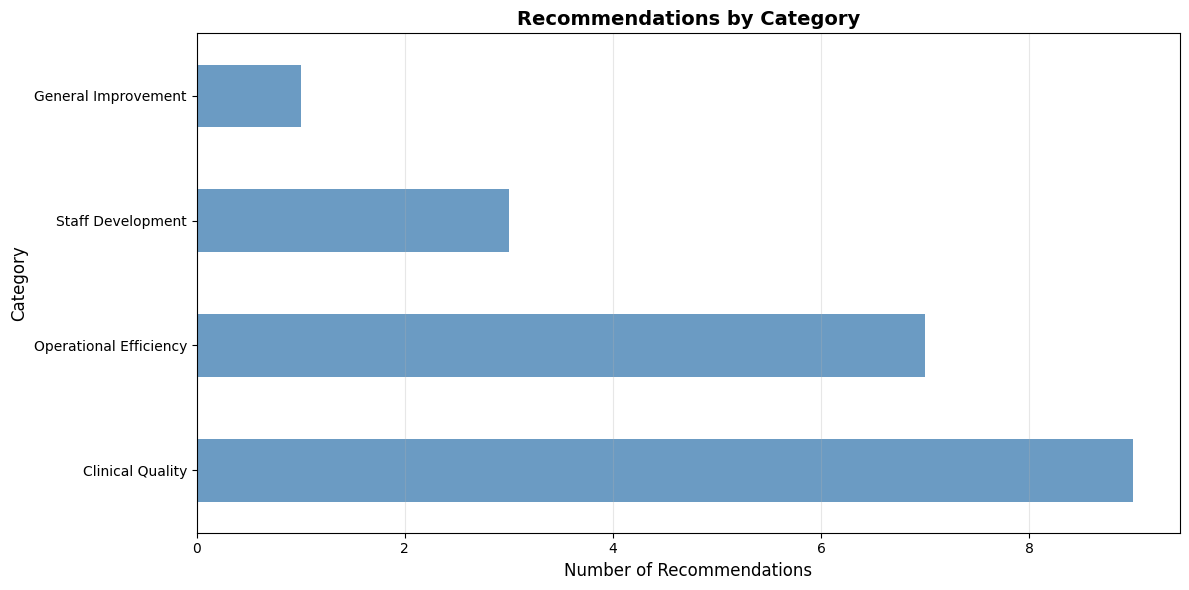

In [35]:
fig, ax = plt.subplots(figsize=(12, 6))
category_counts = recommendations_df[recommendations_df['action_priority'] == 1]['issue_category'].value_counts()
category_counts.plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_xlabel('Number of Recommendations', fontsize=12)
ax.set_ylabel('Category', fontsize=12)
ax.set_title('Recommendations by Category', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig(f'{main_directory}outputs/figures/14_recommendations_by_category.png', dpi=300, bbox_inches='tight')
plt.close()

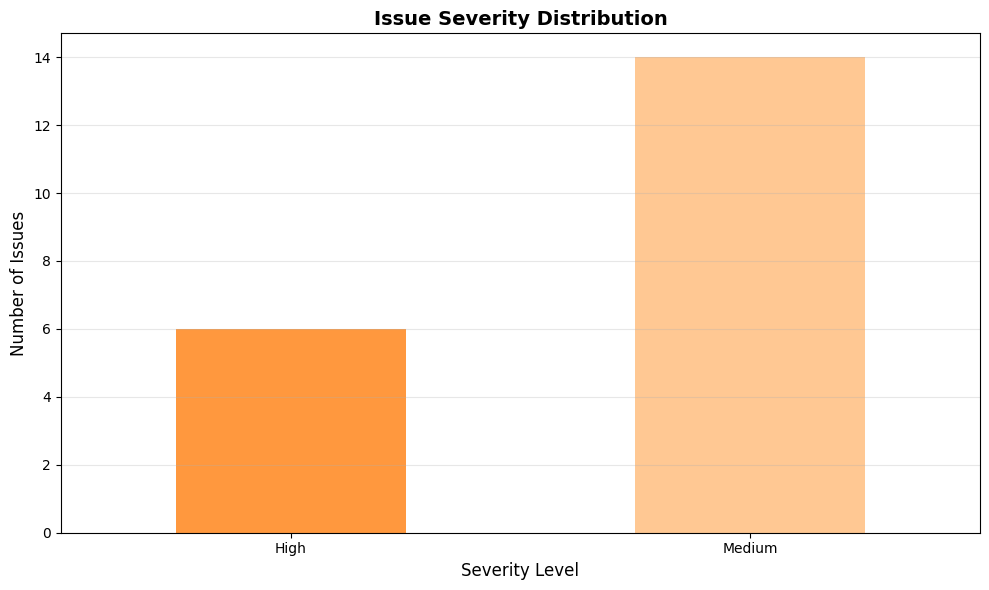

In [36]:
# 2. Severity distribution
fig, ax = plt.subplots(figsize=(10, 6))
severity_counts = recommendations_df[recommendations_df['action_priority'] == 1]['severity_level'].value_counts()
severity_order = ['Critical', 'High', 'Medium', 'Low']
severity_counts = severity_counts.reindex([s for s in severity_order if s in severity_counts.index])

colors = {'Critical': '#d62728', 'High': '#ff7f0e', 'Medium': '#ffbb78', 'Low': '#98df8a'}
bar_colors = [colors[s] for s in severity_counts.index]

severity_counts.plot(kind='bar', ax=ax, color=bar_colors, alpha=0.8)
ax.set_xlabel('Severity Level', fontsize=12)
ax.set_ylabel('Number of Issues', fontsize=12)
ax.set_title('Issue Severity Distribution', fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig(f'{main_directory}outputs/figures/15_severity_distribution.png', dpi=300, bbox_inches='tight')
plt.close()

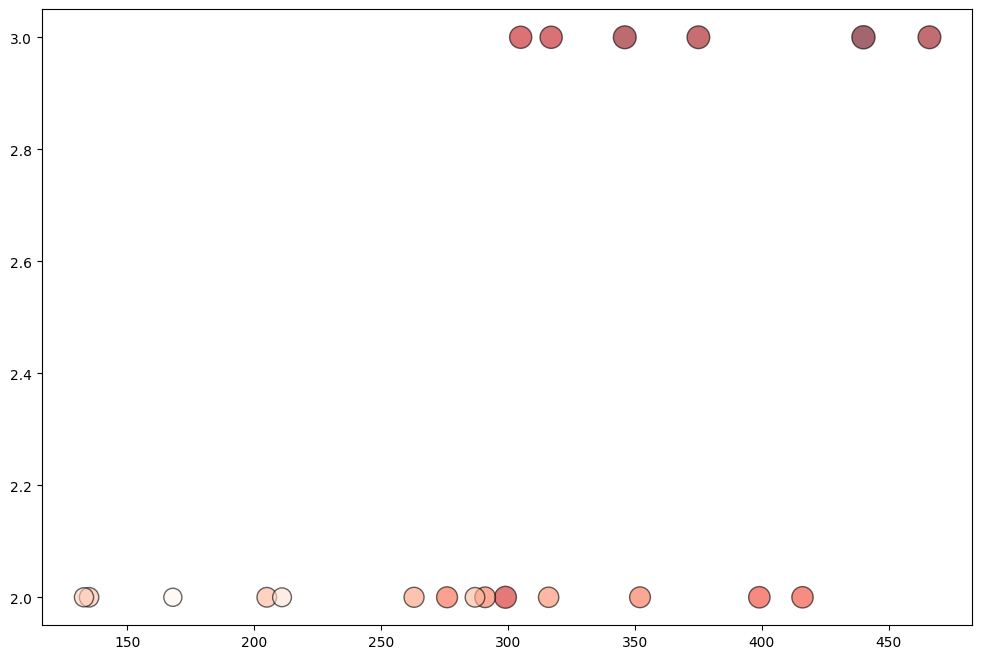

In [37]:
# 3. Impact vs Severity scatter
fig, ax = plt.subplots(figsize=(12, 8))

severity_numeric = {'Critical': 4, 'High': 3, 'Medium': 2, 'Low': 1}
top_recs = recommendations_df[recommendations_df['action_priority'] == 1].copy()
top_recs['severity_numeric'] = top_recs['severity_level'].map(severity_numeric)

scatter = ax.scatter(
    top_recs['affected_patients'],
    top_recs['severity_numeric'],
    s=top_recs['severity_score'] * 5,
    c=top_recs['severity_score'],
    cmap='Reds',
    alpha=0.6,
    edgecolors='black',
    linewidth=1
)

In [39]:
for _, row in top_recommendations.head(5).iterrows():
    ax.annotate(
        f"C{int(row['cluster_id'])}",
        (row['affected_patients'], severity_numeric[row['severity_level']]),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold'
    )

ax.set_xlabel('Number of Affected Patients', fontsize=12)
ax.set_ylabel('Severity Level', fontsize=12)
ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(['Low', 'Medium', 'High', 'Critical'])
ax.set_title('Recommendation Impact vs Severity', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Severity Score')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig(f'{main_directory}outputs/figures/16_impact_vs_severity.png', dpi=300, bbox_inches='tight')
plt.close()

<Figure size 640x480 with 0 Axes>

In [40]:
action_plan = recommendations_df[recommendations_df['action_priority'] == 1].groupby(
    ['issue_category', 'severity_level']
).agg({
    'cluster_id': 'count',
    'affected_patients': 'sum',
    'severity_score': 'mean'
}).reset_index()

action_plan.columns = ['Category', 'Severity', 'Number_of_Issues', 'Total_Affected_Patients', 'Avg_Severity_Score']
action_plan = action_plan.sort_values('Avg_Severity_Score', ascending=False)

print("ACTION PLAN BY CATEGORY & SEVERITY:\n")
print(action_plan.to_string(index=False))

action_plan.to_csv(f'{main_directory}outputs/recommendations/executive_action_plan.csv', index=False)


timeline = {
    'Immediate (0-30 days)': top_recommendations[top_recommendations['severity_level'] == 'Critical'].shape[0],
    'Short-term (1-3 months)': top_recommendations[top_recommendations['severity_level'] == 'High'].shape[0],
    'Medium-term (3-6 months)': top_recommendations[top_recommendations['severity_level'] == 'Medium'].shape[0],
    'Long-term (6-12 months)': top_recommendations[top_recommendations['severity_level'] == 'Low'].shape[0]
}

print("IMPLEMENTATION PHASES:")
for phase, count in timeline.items():
    if count > 0:
        print(f"   {phase}: {count} recommendations")


ACTION PLAN BY CATEGORY & SEVERITY:

              Category Severity  Number_of_Issues  Total_Affected_Patients  Avg_Severity_Score
      Clinical Quality     High                 4                     1586           53.310000
Operational Efficiency     High                 2                      663           52.505000
      Clinical Quality   Medium                 5                     1360           43.138000
     Staff Development   Medium                 3                      966           42.803333
Operational Efficiency   Medium                 5                     1257           42.396000
   General Improvement   Medium                 1                      168           34.010000
IMPLEMENTATION PHASES:
   Short-term (1-3 months): 6 recommendations
   Medium-term (3-6 months): 4 recommendations


In [44]:
summary_stats = {
    'total_recommendations_generated': len(recommendations_df),
    'unique_clusters_analyzed': recommendations_df['cluster_id'].nunique(),
    'critical_issues': len(recommendations_df[recommendations_df['severity_level'] == 'Critical']),
    'high_priority_issues': len(recommendations_df[recommendations_df['severity_level'] == 'High']),
    'total_patients_affected': int(recommendations_df['affected_patients'].sum()),
    'categories_identified': recommendations_df['issue_category'].nunique(),
    'avg_severity_score': round(recommendations_df['severity_score'].mean(), 2)
}

print("KEY STATISTICS:")
for key, value in summary_stats.items():
    print(f"   {key.replace('_', ' ').title()}: {value}")

with open(f'{main_directory}outputs/recommendations/recommendation_summary.json', 'w') as f:
    json.dump(summary_stats, f, indent=2)

print("PHASE 5 COMPLETE: RECOMMENDATIONS GENERATED")
print("\nKey outputs:")
print("1. recommendations.csv - All recommendations")
print("2. top_10_recommendations.csv - Top priority actions")
print("3. top_3_detailed_justification.json - Detailed business case")
print("4. executive_action_plan.csv - Grouped action plan")
print("5. Visualizations saved to outputs/figures/")
print("\nNext steps:")
print("1. Review outputs/recommendations/ folder")
print("2. Proceed to 06_dashboard.py - Build Streamlit dashboard")
print("3. Final presentation preparation")

KEY STATISTICS:
   Total Recommendations Generated: 60
   Unique Clusters Analyzed: 20
   Critical Issues: 0
   High Priority Issues: 18
   Total Patients Affected: 18000
   Categories Identified: 4
   Avg Severity Score: 45.42
PHASE 5 COMPLETE: RECOMMENDATIONS GENERATED

Key outputs:
1. recommendations.csv - All recommendations
2. top_10_recommendations.csv - Top priority actions
3. top_3_detailed_justification.json - Detailed business case
4. executive_action_plan.csv - Grouped action plan
5. Visualizations saved to outputs/figures/

Next steps:
1. Review outputs/recommendations/ folder
2. Proceed to 06_dashboard.py - Build Streamlit dashboard
3. Final presentation preparation
